>>> Processing files...
   -> Loaded Results_Pareto_1_100pct.xlsx | Cost: 2203.8 | Emi: 6606.7 | Total Water: 7468.4 MMGal
   -> Loaded Results_Pareto_1_90pct.xlsx | Cost: 2232.5 | Emi: 6030.0 | Total Water: 7195.5 MMGal
   -> Loaded Results_Pareto_2_80pct.xlsx | Cost: 2294.1 | Emi: 5360.0 | Total Water: 6886.5 MMGal
   -> Loaded Results_Pareto_3_60pct.xlsx | Cost: 2603.1 | Emi: 4020.0 | Total Water: 7165.0 MMGal
   -> Loaded Results_Pareto_4_50pct.xlsx | Cost: 3234.2 | Emi: 3350.0 | Total Water: 6500.7 MMGal


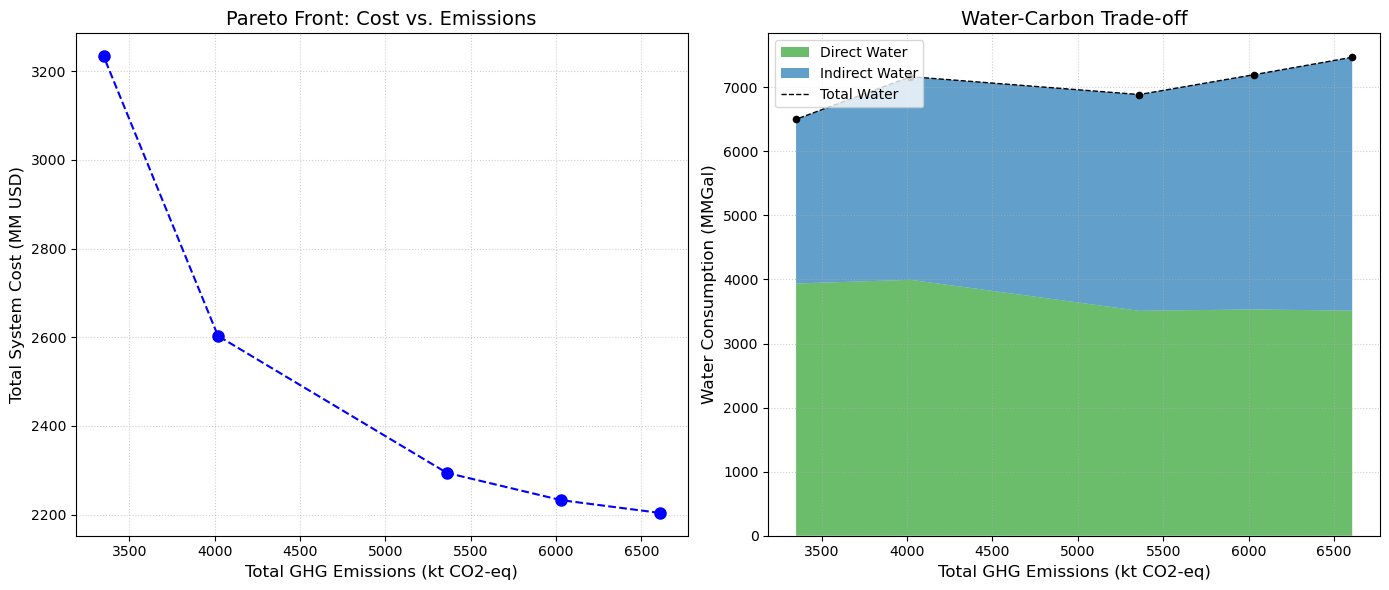

In [5]:
using DataFrames, XLSX, PyPlot, Statistics

# ==========================================
# 1. Configuration
# ==========================================
# Updated file names based on the VS Code explorer image
# Removed '%' from the labels as requested
files_info = [
    (1, "100", "Results_Pareto_1_100pct.xlsx"),
    (2, "90",  "Results_Pareto_1_90pct.xlsx"),
    (3, "80",  "Results_Pareto_2_80pct.xlsx"),
    (4, "60",  "Results_Pareto_3_60pct.xlsx"),
    (5, "50",  "Results_Pareto_4_50pct.xlsx"),
    # (6, "45",  "Results_Pareto_1_45pct.xlsx")
]

df_results = DataFrame(
    Label = String[], 
    Emissions = Float64[], 
    Cost = Float64[], 
    Water_Total = Float64[], 
    Water_Direct = Float64[], 
    Water_Indirect = Float64[]
)

println(">>> Processing files...")

# ==========================================
# 2. Data Extraction
# ==========================================
for (case_num, label, fname) in files_info
    if !isfile(fname)
        println("⚠️ Warning: File not found: $fname")
        continue
    end

    xf = XLSX.readxlsx(fname)

    # -------------------------------------------------------
    # A. EMISSIONS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, and 4 to get Total Emissions (Man + Op + Dec).
    sh_emi = DataFrame(XLSX.gettable(xf["Emissions_summary"]))
    
    # Find "Total" row index
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = sh_emi[total_row_idx, 2] + sh_emi[total_row_idx, 3] + sh_emi[total_row_idx, 4]
    else
        # Fallback: Sum entire columns
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # -------------------------------------------------------
    # B. COSTS (Robust Method)
    # -------------------------------------------------------
    # We sum Cols 2, 3, 4, and 5 (Inv + FixOM + VarOM + Dec)
    sh_cost = DataFrame(XLSX.gettable(xf["Costs_summary"]))
    total_row_cost_idx = findfirst(x -> string(x) == "Total", sh_cost[!, 1])
    
    val_cost = 0.0
    if !isnothing(total_row_cost_idx)
        val_cost = sh_cost[total_row_cost_idx, 2] + 
                   sh_cost[total_row_cost_idx, 3] + 
                   sh_cost[total_row_cost_idx, 4] + 
                   sh_cost[total_row_cost_idx, 5]
    else
        val_cost = sum(sh_cost[!, 2]) + sum(sh_cost[!, 3]) + 
                   sum(sh_cost[!, 4]) + sum(sh_cost[!, 5])
    end

    # -------------------------------------------------------
    # C. WATER (Name Matching)
    # -------------------------------------------------------
    # Values in these files are already in MMGal thanks to the new Results.jl
    sh_water = DataFrame(XLSX.gettable(xf["Water_Consumption"]))
    
    # Helper to find column index by partial string match (handles new MMGal headers automatically)
    function get_col_sum(df, name_part)
        c = findfirst(n -> occursin(lowercase(name_part), lowercase(string(n))), names(df))
        return isnothing(c) ? 0.0 : sum(df[!, c])
    end

    val_indirect = get_col_sum(sh_water, "Grid_Indirect")
    
    direct_keywords = ["DC_Direct", "Cogen_Direct", "Boiler_Direct", "Nuclear_Direct", "Chillers_Direct"]
    val_direct = sum(get_col_sum(sh_water, k) for k in direct_keywords)
    
    push!(df_results, (label, val_emi, val_cost, val_direct + val_indirect, val_direct, val_indirect))
    println("   -> Loaded $fname | Cost: $(round(val_cost, digits=1)) | Emi: $(round(val_emi, digits=1)) | Total Water: $(round(val_direct + val_indirect, digits=1)) MMGal")
end

# Sort Descending (High Emission -> Low Emission)
sort!(df_results, :Emissions, rev=true)

# ==========================================
# 3. Plotting
# ==========================================
fig, (ax1, ax2) = PyPlot.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Pareto ---
ax1.plot(df_results.Emissions, df_results.Cost, marker="o", linestyle="--", color="b", markersize=8)
# for i in 1:nrow(df_results)
#     ax1.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Cost[i]), 
#                  xytext=(5, 5), textcoords="offset points", fontweight="bold")
# end
ax1.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)
ax1.set_ylabel("Total System Cost (MM USD)", fontsize=12)
ax1.set_title("Pareto Front: Cost vs. Emissions", fontsize=14)
ax1.grid(true, linestyle=":", alpha=0.6)

# --- Plot 2: Water Trade-off ---
ax2.stackplot(df_results.Emissions, df_results.Water_Direct, df_results.Water_Indirect, 
              labels=["Direct Water", "Indirect Water"], colors=["#2ca02c", "#1f77b4"], alpha=0.7)
ax2.plot(df_results.Emissions, df_results.Water_Total, color="k", linestyle="--", linewidth=1, label="Total Water")
ax2.scatter(df_results.Emissions, df_results.Water_Total, color="k", s=20)

# for i in 1:nrow(df_results)
#     ax2.annotate(df_results.Label[i], 
#                  xy=(df_results.Emissions[i], df_results.Water_Total[i]), 
#                  xytext=(0, 10), textcoords="offset points", ha="center")
# end
ax2.set_xlabel("Total GHG Emissions (kt CO2-eq)", fontsize=12)

# UPDATED: Y-axis label explicitly states MMGal
ax2.set_ylabel("Water Consumption (MMGal)", fontsize=12)
ax2.set_title("Water-Carbon Trade-off", fontsize=14)
ax2.legend(loc="upper left")
ax2.grid(true, linestyle=":", alpha=0.6)

PyPlot.tight_layout()
display(fig)

>>> Loading Availability Factors from Model_Data.xlsx...

>>> Processing files for Case 1...
   -> Extracted: EMI = 600.6 kt/yr | Curtailment = 131.8 GWh/yr
   -> Extracted: EMI = 548.2 kt/yr | Curtailment = 183.7 GWh/yr
   -> Extracted: EMI = 487.3 kt/yr | Curtailment = 252.2 GWh/yr
   -> Extracted: EMI = 365.5 kt/yr | Curtailment = 543.3 GWh/yr
   -> Extracted: EMI = 304.5 kt/yr | Curtailment = 963.2 GWh/yr
   -> Extracted: EMI = 274.1 kt/yr | Curtailment = 907.1 GWh/yr

>>> Processing files for Case 6...
   -> Extracted: EMI = 632.1 kt/yr | Curtailment = 145.2 GWh/yr
   -> Extracted: EMI = 572.7 kt/yr | Curtailment = 203.0 GWh/yr
   -> Extracted: EMI = 509.1 kt/yr | Curtailment = 303.6 GWh/yr
   -> Extracted: EMI = 381.8 kt/yr | Curtailment = 713.3 GWh/yr
   -> Extracted: EMI = 318.2 kt/yr | Curtailment = 796.7 GWh/yr
   -> Extracted: EMI = 286.4 kt/yr | Curtailment = 907.0 GWh/yr


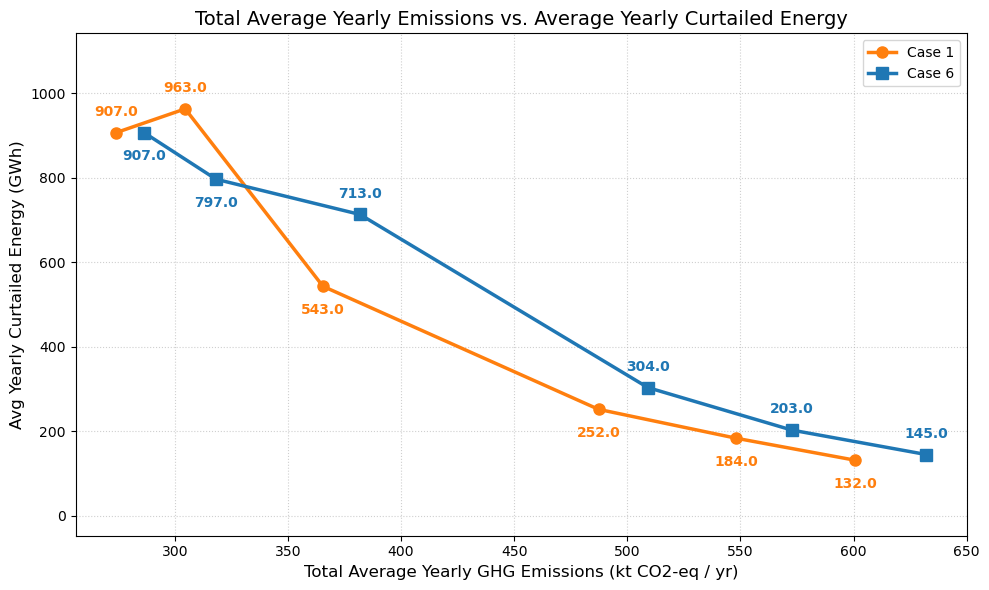

In [9]:
using DataFrames, XLSX, PyPlot

# ==========================================
# 1. Configuration & Setup
# ==========================================
# Assuming standard Model_Data.xlsx is in the same directory
model_data_path = "Model_Data.xlsx"

# Exact file names from your VS Code explorer screenshot
file_names = [
    "Results_Pareto_1_100pct.xlsx",
    "Results_Pareto_1_90pct.xlsx",
    "Results_Pareto_2_80pct.xlsx",
    "Results_Pareto_3_60pct.xlsx",
    "Results_Pareto_4_50pct.xlsx",
    "Results_Pareto_1_45pct.xlsx"
]

# Define the cases and their respective folder paths
cases = Dict(
    "Case 1"   => "./", 
    "Case 6" => "../Emission_Cost_Pareto_Case_6/" # <-- Adjust if your Case 6 folder name is different
)

println(">>> Loading Availability Factors from Model_Data.xlsx...")

# ==========================================
# 2. Extract Availability from Model_Data
# ==========================================
xf_model = XLSX.readxlsx(model_data_path)

# A. Read PT (Performance Loss) and cap_t (Turbine Capacity)
df_mod = DataFrame(XLSX.gettable(xf_model["Model_Data"]))
PT = Dict{String, Float64}()
cap_t = Dict{String, Float64}()

for row in eachrow(df_mod)
    param = String(row.Parameter)
    tech = lowercase(String(row.Technology))
    if param == "PT"
        PT[tech] = Float64(row.Value)
    elseif param == "cap_t"
        cap_t[tech] = Float64(row.Value)
    end
end

# B. Read Annual Sums of HL (Solar Load Factor) and WP (Wind Power)
function get_annual_sums(sheet_name)
    df = DataFrame(XLSX.gettable(xf_model[sheet_name]))
    sums = Dict{Int, Float64}()
    for col in names(df)
        col_str = String(col)
        if col_str != "hours" && col_str != "Hour"
            y = parse(Int, col_str)
            sums[y] = sum(coalesce.(df[!, col], 0.0))
        end
    end
    return sums
end

sum_hl = get_annual_sums("HL")
sum_wp = get_annual_sums("WP")

# ==========================================
# 3. Data Extraction Logic
# ==========================================
function get_emissions_and_curtailment(filepath)
    if !isfile(filepath)
        println("   ⚠️ Warning: File not found: $filepath")
        return (0.0, 0.0)
    end
    
    xf_res = XLSX.readxlsx(filepath)
    
    # --- 1. Total Emissions ---
    sh_emi = DataFrame(XLSX.gettable(xf_res["Emissions_summary"]))
    total_row_idx = findfirst(x -> string(x) == "Total", sh_emi[!, 1])
    val_emi = 0.0
    if !isnothing(total_row_idx)
        val_emi = Float64(sh_emi[total_row_idx, 2]) + Float64(sh_emi[total_row_idx, 3]) + Float64(sh_emi[total_row_idx, 4])
    else
        val_emi = sum(sh_emi[!, 2]) + sum(sh_emi[!, 3]) + sum(sh_emi[!, 4])
    end

    # --- 2. Average Yearly Curtailment ---
    df_gen = DataFrame(XLSX.gettable(xf_res["Generation_Summary"]))
    df_cap = DataFrame(XLSX.gettable(xf_res["Capacity_Exp_Dec"]))
    
    # Exclude the 2025 initialization year
    filter!(row -> row.Year != 2025, df_gen)
    filter!(row -> row.Year != 2025, df_cap)
    
    n_years = nrow(df_gen)
    if n_years == 0; return (val_emi, 0.0); end
    
    total_curtailment_all_years = 0.0
    
    for i in 1:n_years
        y = Int(df_gen[i, :Year])
        
        for tech_col in names(df_gen)
            if String(tech_col) in ["Year", "Grid", "Grid_Energy_MWh"]
                continue
            end
            
            t = String(tech_col)
            t_lower = lowercase(t)
            
            # Check if it's Variable Renewable Energy (VRES)
            is_solar = occursin("pv", t_lower) || occursin("solar", t_lower)
            is_wind = occursin("wt", t_lower) || occursin("wind", t_lower)
            
            if !is_solar && !is_wind
                continue # Ignore baseload/dispatchable tech
            end
            
            # Actual Generation (already includes energy sent to batteries for charging)
            gen_gwh = Float64(df_gen[i, tech_col])
            
            # Installed Capacity
            cap_col = Symbol("$t Cap")
            cap_val = hasproperty(df_cap, cap_col) ? Float64(df_cap[i, cap_col]) : 0.0
            
            # Calculate Available Generation based on Capacity and Weather files
            avail_mwh = 0.0
            if is_solar
                pt_val = get(PT, t_lower, 0.0)
                avail_mwh = cap_val * get(sum_hl, y, 0.0) * (1 - pt_val)
            elseif is_wind
                capt_val = get(cap_t, t_lower, 1.0)
                turbines = cap_val / capt_val
                avail_mwh = turbines * get(sum_wp, y, 0.0)
            end
            
            avail_gwh = avail_mwh / 1000.0
            
            # Curtailment = Available - Actual (Charging naturally ignored because Actual includes it)
            curt_gwh = max(0.0, avail_gwh - gen_gwh)
            total_curtailment_all_years += curt_gwh
        end
    end
    
    avg_curtailment = total_curtailment_all_years / n_years
    avg_yearly_emi = val_emi / n_years # Convert cumulative emissions to yearly average
    
    return (avg_yearly_emi, avg_curtailment)
end

# Extract data for all cases
results_data = Dict{String, Vector{Tuple{Float64, Float64}}}()

for (case_name, dir_path) in cases
    println("\n>>> Processing files for $case_name...")
    pts = Tuple{Float64, Float64}[]
    
    for fname in file_names
        filepath = joinpath(dir_path, fname)
        emi, curt = get_emissions_and_curtailment(filepath)
        if emi > 0.0
            push!(pts, (emi, curt))
            println("   -> Extracted: EMI = $(round(emi, digits=1)) kt/yr | Curtailment = $(round(curt, digits=1)) GWh/yr")
        end
    end
    
    # NEW: Sort points from Lowest Emission to Highest Emission (ASCENDING order)
    sort!(pts, by = x -> x[1]) 
    results_data[case_name] = pts
end

# ==========================================
# 4. Plotting
# ==========================================
fig, ax = PyPlot.subplots(figsize=(10, 6))

plot_styles = Dict(
    "Case 1"   => Dict(:color => "#ff7f0e", :marker => "o"), # Orange
    "Case 6" => Dict(:color => "#1f77b4", :marker => "s")  # Blue
)

# A. Draw the lines and markers
for (case_name, pts) in results_data
    if isempty(pts); continue; end
    style = plot_styles[case_name]
    
    x_vals = [p[1] for p in pts]
    y_vals = [p[2] for p in pts]
    
    ax.plot(x_vals, y_vals, marker=style[:marker], linestyle="-", color=style[:color], 
            linewidth=2.5, markersize=8, label=case_name)
end

# B. Dynamically place text annotations to avoid overlap
case_names = collect(keys(results_data))
if length(case_names) == 2
    name_A = case_names[1]
    name_B = case_names[2]
    
    pts_A = results_data[name_A]
    pts_B = results_data[name_B]
    
    # Assume they have the same number of matching points
    n_pts = min(length(pts_A), length(pts_B))
    
    for i in 1:n_pts
        x_A, y_A = pts_A[i]
        x_B, y_B = pts_B[i]
        
        # Compare Y values: higher value text goes UP, lower value text goes DOWN
        if y_A >= y_B
            offset_A, va_A = 10, "bottom"
            offset_B, va_B = -12, "top"
        else
            offset_A, va_A = -12, "top"
            offset_B, va_B = 10, "bottom"
        end
        
        # Annotate Case A
        ax.annotate(string(round(y_A, digits=0)), 
                    xy=(x_A, y_A), xytext=(0, offset_A), textcoords="offset points", 
                    ha="center", va=va_A, fontsize=10, fontweight="bold", color=plot_styles[name_A][:color])
                    
        # Annotate Case B
        ax.annotate(string(round(y_B, digits=0)), 
                    xy=(x_B, y_B), xytext=(0, offset_B), textcoords="offset points", 
                    ha="center", va=va_B, fontsize=10, fontweight="bold", color=plot_styles[name_B][:color])
    end
end

ax.set_title("Total Average Yearly Emissions vs. Average Yearly Curtailed Energy", fontsize=14)
ax.set_xlabel("Total Average Yearly GHG Emissions (kt CO2-eq / yr)", fontsize=12) # Updated Axis Label
ax.set_ylabel("Avg Yearly Curtailed Energy (GWh)", fontsize=12)
ax.grid(true, linestyle=":", alpha=0.6)

# Adjust Y-axis limits slightly to ensure annotations aren't cut off
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min - (y_max - y_min) * 0.15, y_max + (y_max - y_min) * 0.15)

ax.legend(loc="upper right")

PyPlot.tight_layout()
display(fig)